In [272]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# 1. Завантаження даних

In [273]:
!wget -O mod_05_topic_10_various_data.pkl \
https://raw.githubusercontent.com/goitacademy/MACHINE-LEARNING-NEO/main/datasets/mod_05_topic_10_various_data.pkl

--2026-07-19 18:02:45--  https://raw.githubusercontent.com/goitacademy/MACHINE-LEARNING-NEO/main/datasets/mod_05_topic_10_various_data.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18343147 (17M) [application/octet-stream]
Saving to: ‘mod_05_topic_10_various_data.pkl’

mod_05_topic_10_var 100%[===================>]  17.49M  --.-KB/s    in 0.08s   

2026-07-19 18:02:46 (215 MB/s) - ‘mod_05_topic_10_various_data.pkl’ saved [18343147/18343147]



In [274]:
with open("mod_05_topic_10_various_data.pkl", "rb") as fl:
    datasets = pickle.load(fl)

In [275]:
df = datasets['autos']

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               193 non-null    object 
 1   fuel_type          193 non-null    object 
 2   aspiration         193 non-null    object 
 3   num_of_doors       193 non-null    int64  
 4   body_style         193 non-null    object 
 5   drive_wheels       193 non-null    object 
 6   engine_location    193 non-null    object 
 7   wheel_base         193 non-null    float64
 8   length             193 non-null    float64
 9   width              193 non-null    float64
 10  height             193 non-null    float64
 11  curb_weight        193 non-null    int64  
 12  engine_type        193 non-null    object 
 13  num_of_cylinders   193 non-null    int64  
 14  engine_size        193 non-null    int64  
 15  fuel_system        193 non-null    object 
 16  bore               193 non

# 2. Визначення дискретних ознак

In [276]:
cat_cols = df.select_dtypes(include='object').columns.to_list()
cat_cols = cat_cols + ['num_of_doors','num_of_cylinders']
cat_cols

['make',
 'fuel_type',
 'aspiration',
 'body_style',
 'drive_wheels',
 'engine_location',
 'engine_type',
 'fuel_system',
 'num_of_doors',
 'num_of_cylinders']

# 3. Розрахунок Mutual Information

In [277]:
X = df.drop(columns="price")
y = df["price"]

In [279]:
# Кодуємо категоріальні/дискретні ознаки. Використовуємо замість TargetEncoder()
for col in cat_cols:
    X[col], _ = pd.factorize(X[col])

In [280]:
mi = mutual_info_regression(
    X,
    y,
    discrete_features = X.columns.isin(cat_cols),
    random_state=42
)

mi_scores = pd.Series(mi, index=X.columns)

# 4. Розбиття на тренувальний та тестовий датасет

In [281]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 5. Побудова Random Forest

In [282]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("R² =", r2_score(y_test, y_pred))
print("MAE =", mean_absolute_error(y_test, y_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)))


R² = 0.9255224524645422
MAE = 1719.3686373108358
RMSE = 2892.9928712027954


In [283]:
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# 6. Побудова Gradient Boosting

In [284]:
gb_model = GradientBoostingRegressor(
    n_estimators=500,
    min_samples_leaf=2,
    max_depth=None, # для відповідності RandomForestRegressor
    random_state=42
)

gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(X_test)

print("R² =", r2_score(y_test, y_pred))
print("MAE =", mean_absolute_error(y_test, y_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)))

R² = 0.9301243620965568
MAE = 1495.1659006343175
RMSE = 2802.1899594641177


In [285]:
gb_importance = pd.Series(
    gb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# 7. Порівняння важливості ознак

In [286]:
importance_df = pd.DataFrame({
    "Mutual Information": mi_scores,
    "Random Forest": rf_importance,
    "Gradient Boosting": gb_importance
})

feature_scores = importance_df.rank(pct=True)

feature_scores = feature_scores.sort_values(by="Mutual Information", ascending=False)

feature_scores

,Mutual Information,Random Forest,Gradient Boosting
curb_weight,1.000000,1.000000,0.956522
engine_size,0.956522,0.956522,1.000000
horsepower,0.913043,0.913043,0.913043
highway_mpg,0.869565,0.826087,0.347826
city_mpg,0.826087,0.434783,0.565217
width,0.782609,0.869565,0.869565
length,0.739130,0.695652,0.739130
wheel_base,0.695652,0.608696,0.434783
make,0.652174,0.782609,0.782609
bore,0.608696,0.521739,0.521739


In [287]:
plot_df = (
    feature_scores
    .reset_index()
    .rename(columns={"index": "feature"})
    .melt(
        id_vars="feature",
        var_name="Method",
        value_name="Score"
    )
)

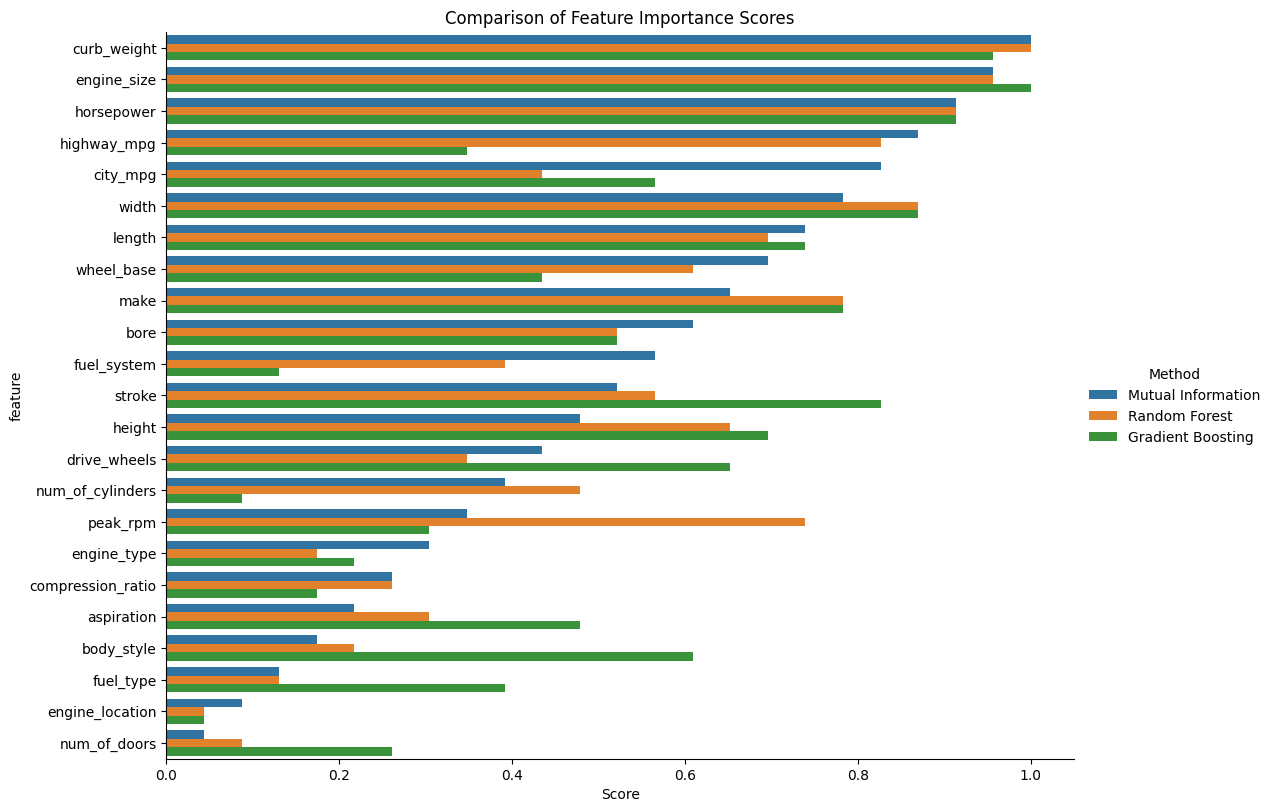

In [288]:
sns.catplot(
    data=plot_df,
    kind="bar",
    x="Score",
    y="feature",
    hue="Method",
    height=8,
    aspect=1.4
)

plt.title("Comparison of Feature Importance Scores")
plt.show()

# Аналіз результатів

Порівняння показало, що всі три методи — Mutual Information, Random Forest та Gradient Boosting — виділяють схожий набір найважливіших ознак для прогнозування ціни автомобіля. Найвищі ранги отримали curb_weight, engine_size та horsepower, що свідчить про їхній найбільший вплив на цільову змінну. Це логічно, оскільки дорожчі автомобілі зазвичай мають більшу масу, потужніший та об'ємніший двигун.

Для більшості інших ознак також спостерігається достатньо висока узгодженість між методами. Наприклад, width, length, make та bore займають близькі позиції у всіх трьох рейтингах, що підтверджує їхню значущість.

Водночас для окремих ознак результати суттєво відрізняються. Наприклад, highway_mpg має високий ранг за Mutual Information та Random Forest, але значно нижчий у Gradient Boosting. Це може свідчити про те, що ця ознака має сильний статистичний зв'язок із ціною, проте частина її інформації вже міститься в інших характеристиках автомобіля, таких як engine_size або horsepower.

Інший приклад — body_style, drive_wheels та stroke, які отримали значно вищі оцінки у Gradient Boosting, ніж за Mutual Information. Це може бути пов'язано з тим, що Gradient Boosting краще враховує складні нелінійні взаємозв'язки між ознаками.

Найнижчі ранги отримали engine_location та num_of_doors. Усі три методи оцінюють їх як малозначущі, що свідчить про незначний вплив цих характеристик на прогнозування ціни автомобіля.

# **Висновок:**

Проведене порівняння показало, що Mutual Information, Random Forest та Gradient Boosting загалом узгоджуються між собою при визначенні найважливіших ознак. Найбільший вплив на ціну автомобіля мають curb_weight, engine_size та horsepower. Відмінності у ранжуванні окремих ознак пояснюються різними принципами оцінювання важливості: Mutual Information аналізує статистичну залежність, тоді як ансамблеві моделі оцінюють реальний внесок ознаки у процес прогнозування. Отримані результати підтверджують, що використання кількох методів дозволяє отримати більш повне уявлення про важливість ознак.